# Pytorch - Red Neuronal (Regresion One vs All Multimodal)

## Datos

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torchvision
from tqdm import tqdm
from matplotlib import pyplot
from scipy import optimize
from scipy.io import loadmat
from sklearn.model_selection import train_test_split

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


=== Dataset completo ===
X_train: (56000, 784)
X_test:  (14000, 784)
y_train: (56000,)
y_test:  (14000,)

Número de ejemplos entrenamiento (m): 56000
Clases únicas: [0 1 2 3 4 5 6 7 8 9]
Ejemplos por clase:
0    5522
1    6302
2    5592
3    5713
4    5459
5    5050
6    5501
7    5834
8    5460
9    5567
Name: count, dtype: int64


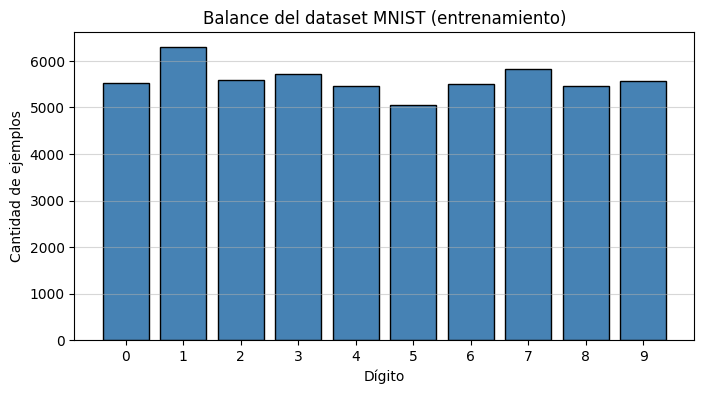

In [3]:
from scipy.io import arff

# Imágenes de dígitos de 28x28
input_layer_size = 784
num_labels = 10

# Cargar el archivo .arff
data, meta = arff.loadarff('/content/drive/MyDrive/SIS420/datasets/datasets_tareas/mnist_784.arff')

# Convertir a DataFrame
df = pd.DataFrame(data)

# Separar X e y
X = df.iloc[:, :-1].values.astype(float)
y = df.iloc[:, -1].values.astype(int)

# Normalizar píxeles de 0-255 a 0-1
X = X / 255.0

# División 80% entrenamiento - 20% testeo
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

m = y_train.size

print("=== Dataset completo ===")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")
print(f"\nNúmero de ejemplos entrenamiento (m): {m}")
print(f"Clases únicas: {np.unique(y_train)}")

# Balance del dataset
balance = pd.Series(y_train).value_counts().sort_index()
print("Ejemplos por clase:")
print(balance)

# Graficar balance
pyplot.figure(figsize=(8, 4))
pyplot.bar(balance.index, balance.values, color='steelblue', edgecolor='black')
pyplot.xlabel('Dígito')
pyplot.ylabel('Cantidad de ejemplos')
pyplot.title('Balance del dataset MNIST (entrenamiento)')
pyplot.xticks(range(10))
pyplot.grid(axis='y', alpha=0.5)
pyplot.show()

## Datos visualizados

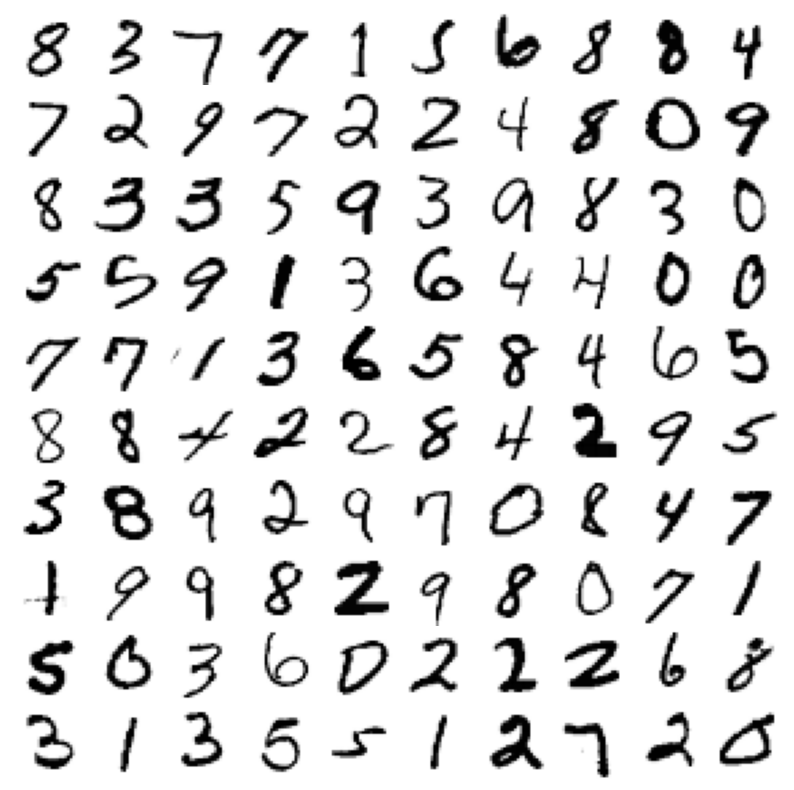

In [4]:
def displayData(X, example_width=None, figsize=(10, 10)):
    if X.ndim == 2:
        m, n = X.shape
    elif X.ndim == 1:
        n = X.size
        m = 1
        X = X[None]
    else:
        raise IndexError('La entrada X debe ser 1 o 2 dimensional.')

    example_width  = example_width or int(np.round(np.sqrt(n)))
    example_height = int(n / example_width)

    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = pyplot.subplots(display_rows, display_cols, figsize=figsize)
    fig.subplots_adjust(wspace=0.025, hspace=0.025)

    ax_array = [ax_array] if m == 1 else ax_array.ravel()

    for i, ax in enumerate(ax_array):
        ax.imshow(X[i].reshape(example_height, example_width, order='C'),
                  cmap='Greys', extent=[0, 1, 0, 1])
        ax.axis('off')

# Mostrar 100 ejemplos aleatorios
rand_indices = np.random.choice(m, 100, replace=False)
sel = X_train[rand_indices, :]
displayData(sel)

## Detectar GPU

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## Tensores

In [6]:
# convertimos datos a tensores y copiamos en gpu
X_t = torch.from_numpy(X_train.astype(np.float32)).float().to(device)
Y_t = torch.from_numpy(y_train.astype(np.int64)).long().to(device)

## Modelos

In [7]:
# Modelo Sequential

D_in  = 784   # 28x28 píxeles
H1    = 128
H2    = 64
D_out = 10    # 10 clases (dígitos 0-9)

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H1),
    torch.nn.ReLU(),
    torch.nn.Linear(H1, H2),
    torch.nn.ReLU(),
    torch.nn.Linear(H2, D_out),
    # sin Sigmoid: CrossEntropyLoss ya incluye Softmax internamente
)

# probar que el modelo recibe los datos en las dimensiones correctas
x_prueba = torch.randn(500, D_in)
outputs = model(x_prueba)
outputs.shape

torch.Size([500, 10])

In [8]:
# Modelo personalizado

class ModeloPersonalizado(torch.nn.Module):

    def __init__(self, D_in, H1, H2, D_out):
        super(ModeloPersonalizado, self).__init__()
        self.fc1   = torch.nn.Linear(D_in, H1)
        self.relu1 = torch.nn.ReLU()
        self.fc2   = torch.nn.Linear(H1, H2)
        self.relu2 = torch.nn.ReLU()
        self.fc3   = torch.nn.Linear(H2, D_out)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

## Dataset y dataloader

In [9]:
class DatasetPersonalizado(torch.utils.data.Dataset):
    # constructor
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X.astype(np.float32)).float().to(device)
        self.Y = torch.from_numpy(Y.astype(np.int64)).long().to(device)
    # devolvemos el número de datos en el dataset
    def __len__(self):
        return len(self.X)
    # devolvemos el elemento ix del dataset
    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

In [10]:
dataloader = {
    'train': torch.utils.data.DataLoader(
                DatasetPersonalizado(X_train, y_train),
                batch_size=256, shuffle=True),
    'test':  torch.utils.data.DataLoader(
                DatasetPersonalizado(X_test, y_test),
                batch_size=256, shuffle=False)
}

x, y_b = next(iter(dataloader['train']))
print(x.shape, y_b.shape)

torch.Size([256, 784]) torch.Size([256])


In [11]:
# Función fit

train_losses = []

def fit(model, dataloader, epochs=200, PATH="./checkpoint.pt"):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.CrossEntropyLoss()  # equivalente al oneVsAll del código original
    best_loss = float("inf")
    for epoch in range(1, epochs+1):
        model.train()
        train_loss = []
        bar = tqdm(dataloader['train'])
        for batch in bar:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
            bar.set_description(f"loss {np.mean(train_loss):.5f}")
        bar = tqdm(dataloader['test'])
        val_loss = []
        model.eval()
        with torch.no_grad():
            for batch in bar:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y)
                val_loss.append(loss.item())
                bar.set_description(f"val_loss {np.mean(val_loss):.5f}")
        # guardar modelo si es el mejor
        val_loss = np.mean(val_loss)
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), PATH)
            print(f"Best model saved at epoch {epoch} with val_loss {val_loss:.5f}")
        print(f"Epoch {epoch}/{epochs} loss {np.mean(train_loss):.5f} val_loss {val_loss:.5f}")
        train_losses.append(np.mean(train_loss))
    # cargar el mejor modelo al final del entrenamiento
    model.load_state_dict(torch.load(PATH))

In [12]:
# Función evaluate

def evaluate(model, dataloader):
    model.eval()
    model.to(device)
    bar = tqdm(dataloader['test'])
    acc = []
    with torch.no_grad():
        for batch in bar:
            X, y = batch
            X, y = X.to(device), y.to(device)
            y_hat = model(X)
            # argmax equivalente a predictOneVsAll del código original
            pred = torch.argmax(y_hat, axis=1)
            acc.append((pred == y).float().mean().item())
            bar.set_description(f"acc {np.mean(acc):.5f}")

## Entrenar y evaluar

In [13]:
model = ModeloPersonalizado(D_in, H1, H2, D_out)
fit(model, dataloader)
evaluate(model, dataloader)

val_loss 0.27614: 100%|██████████| 55/55 [00:00<00:00, 281.39it/s]


Best model saved at epoch 1 with val_loss 0.27614
Epoch 1/200 loss 0.56402 val_loss 0.27614


val_loss 0.19972: 100%|██████████| 55/55 [00:00<00:00, 284.34it/s]


Best model saved at epoch 2 with val_loss 0.19972
Epoch 2/200 loss 0.22598 val_loss 0.19972


val_loss 0.15784: 100%|██████████| 55/55 [00:00<00:00, 292.93it/s]


...

val_loss 0.25270: 100%|██████████| 55/55 [00:00<00:00, 241.82it/s]


Epoch 199/200 loss 0.00000 val_loss 0.25270


val_loss 0.25510: 100%|██████████| 55/55 [00:00<00:00, 184.42it/s]


Epoch 200/200 loss 0.00000 val_loss 0.25510


acc 0.97611: 100%|██████████| 55/55 [00:00<00:00, 133.15it/s]


## Gráfica de convergencia

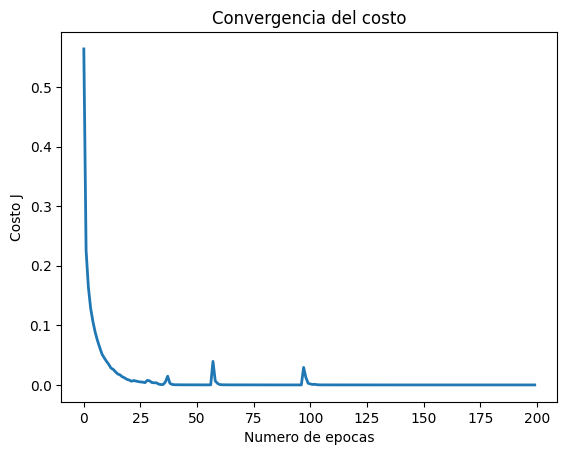

In [14]:
pyplot.plot(np.arange(len(train_losses)), train_losses, lw=2)
pyplot.xlabel('Numero de epocas')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del costo')
pyplot.show()

## Dataset y dataloader

In [27]:
# Dataset personalizado
class DatasetPersonalizado(torch.utils.data.Dataset):
    # constructor
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X.astype(np.float32)).float().to(device)
        self.Y = torch.from_numpy(Y.astype(np.int64)).long().to(device)
    # devolvemos el número de datos en el dataset
    def __len__(self):
        return len(self.X)
    # devolvemos el elemento ix del dataset
    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

# DataLoader igual que el código 4 de referencia
dataloader = {
    'train': torch.utils.data.DataLoader(
                DatasetPersonalizado(X_train, y_train),
                batch_size=2048, shuffle=True, pin_memory=False),
    'test':  torch.utils.data.DataLoader(
                DatasetPersonalizado(X_test, y_test),
                batch_size=2048, shuffle=False, pin_memory=False)
}

x, y_b = next(iter(dataloader['train']))
print(x.shape, y_b.shape)

torch.Size([2048, 784]) torch.Size([2048])


## Prediccion

In [28]:
model.to(device)
model.eval()

with torch.no_grad():
    pred_train = torch.argmax(
        model(torch.from_numpy(X_train.astype(np.float32)).to(device)), axis=1
    ).cpu().numpy()

    pred_test = torch.argmax(
        model(torch.from_numpy(X_test.astype(np.float32)).to(device)), axis=1
    ).cpu().numpy()

print('Precisión del conjunto de entrenamiento: {:.2f}%'.format(np.mean(pred_train == y_train) * 100))
print('Precisión del conjunto de testeo:        {:.2f}%'.format(np.mean(pred_test  == y_test)  * 100))

Precisión del conjunto de entrenamiento: 99.45%
Precisión del conjunto de testeo:        97.61%


## Prueba visual 12 ejemplos

Predicciones:    [7 3 1 1 2 5 9 3 8 1 6 6]
Etiquetas reales:[7 3 1 1 2 5 9 8 8 1 6 6]
Aciertos en muestra visual: 11/12


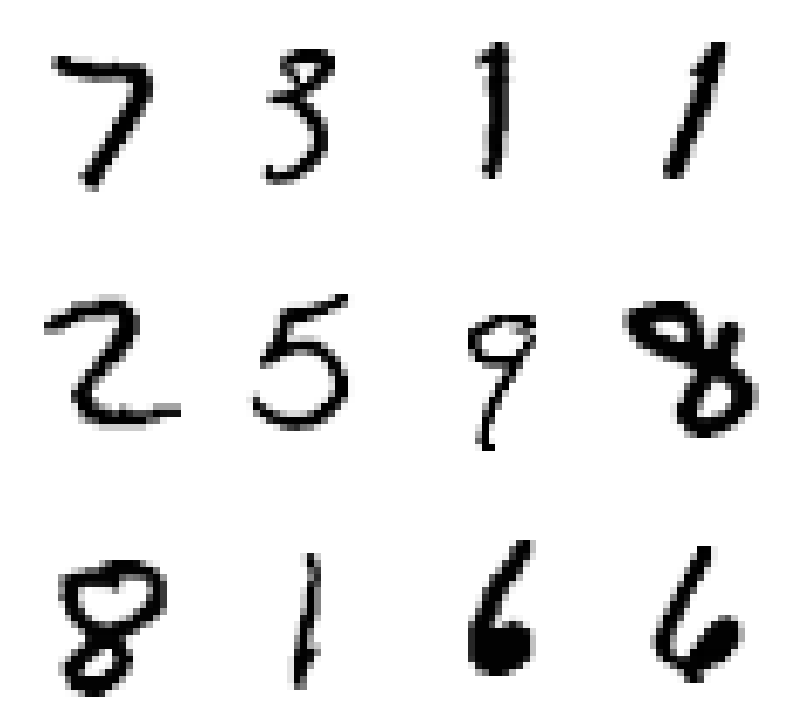

In [29]:
# prueba visual con 12 ejemplos del conjunto de testeo
XPrueba = X_test[0:12, :].copy()

with torch.no_grad():
    p = torch.argmax(
        model(torch.from_numpy(XPrueba.astype(np.float32)).to(device)), axis=1
    ).cpu().numpy()

print(f'Predicciones:    {p}')
print(f'Etiquetas reales:{y_test[0:12]}')

aciertos = np.sum(p == y_test[0:12])
print(f'Aciertos en muestra visual: {aciertos}/12')

displayData(X_test[0:12, :])

## TorchScript

In [30]:
x = torch.randn(1, D_in)
traced_model = torch.jit.trace(model.cpu(), x)
traced_model.save('model.zip')

loaded_model = torch.jit.load('model.zip')

scripted_model = torch.jit.script(model.cpu())
scripted_model.save('model.zip')

loaded_model = torch.jit.load('model.zip')

## Export ONNX

In [19]:
!pip install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 19.5 MB/s eta 0:00:00


In [31]:
x = torch.randn(1, D_in)

torch.onnx.export(model.cpu(),
                  x,
                  "model.onnx",
                  export_params=True,
                  opset_version=10,
                  do_constant_folding=True,
                  input_names=['input'],
                  output_names=['output'],
                  dynamic_axes={'input':  {0: 'batch_size'},
                                'output': {0: 'batch_size'}})

/tmp/ipykernel_1688/2817503493.py:3: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(model.cpu(),
W0331 02:22:45.077000 1688 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 10 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0331 02:22:45.874000 1688 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'i

[torch.onnx] Obtain model graph for `ModeloPersonalizado([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ModeloPersonalizado([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[batch_size,784]>
            ),
            outputs=(
                %"output"<FLOAT,[batch_size,10]>
            ),
            initializers=(
                %"fc1.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"fc2.bias"<FLOAT,[64]>{TorchTensor(...)},
                %"fc3.weight"<FLOAT,[10,64]>{TorchTensor(...)},
                %"fc3.bias"<FLOAT,[10]>{TorchTensor<FLOAT,[10]>(Parameter containing: tensor([-0.1563, -0.0683, -0.0321, -0.0046, -0.0638,  0.0062, -0.0366,  0.0053, 0.0425,  0.0164], requires_grad=True), name='fc3.bias')},
                %"fc1.weight"<FLOAT,[128,784]>{TorchTensor(...)},
                %"fc2.weight"<FLOAT,[64

## Gráfico de costo por clase

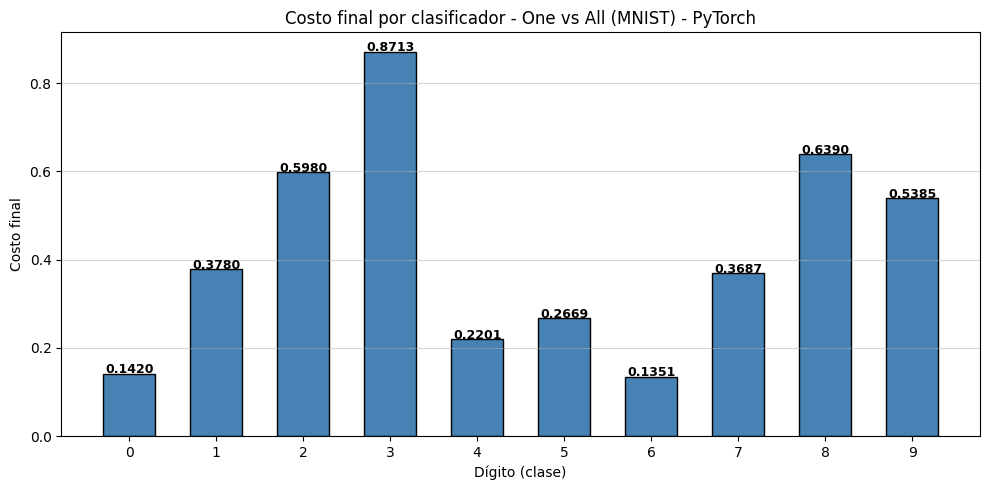

In [32]:
# costo final por clase usando el modelo PyTorch
model.to(device)
model.eval()
criterion = torch.nn.CrossEntropyLoss()
costos = []

with torch.no_grad():
    for c in range(num_labels):
        X_t = torch.from_numpy(X_train.astype(np.float32)).to(device)
        y_c = torch.from_numpy((y_train == c).astype(np.int64)).to(device)
        y_hat = model(X_t)
        # costo binario para cada clase (one vs all)
        y_hat_c = y_hat[:, c]
        loss = torch.nn.BCEWithLogitsLoss()(y_hat_c, y_c.float())
        costos.append(loss.item())

pyplot.figure(figsize=(10, 5))
barras = pyplot.bar(range(num_labels), costos, color='steelblue', edgecolor='black', width=0.6)

for i, (barra, c) in enumerate(zip(barras, costos)):
    pyplot.text(barra.get_x() + barra.get_width()/2,
                c + 0.001, f'{c:.4f}', ha='center', fontsize=9, fontweight='bold')

pyplot.xlabel('Dígito (clase)')
pyplot.ylabel('Costo final')
pyplot.title('Costo final por clasificador - One vs All (MNIST) - PyTorch')
pyplot.xticks(range(10))
pyplot.grid(axis='y', alpha=0.5)
pyplot.tight_layout()
pyplot.show()

## Gráfica precisión entrenamiento vs testeo

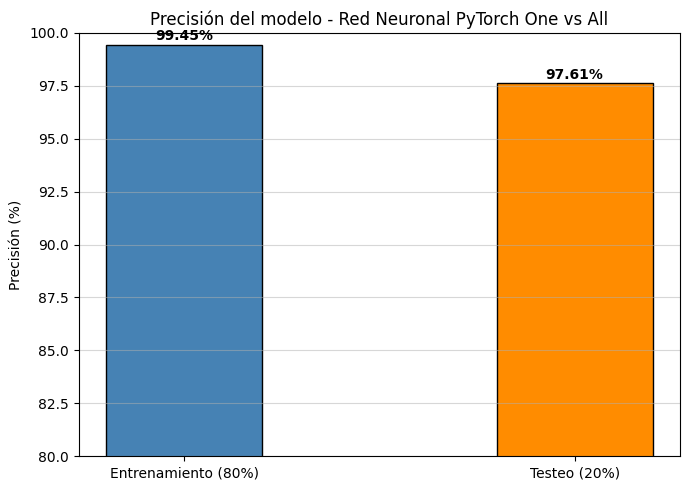

Precisión entrenamiento: 99.45%
Precisión testeo:        97.61%


In [33]:
precision_train = np.mean(pred_train == y_train) * 100
precision_test  = np.mean(pred_test  == y_test)  * 100

pyplot.figure(figsize=(7, 5))
barras = pyplot.bar(
    ['Entrenamiento (80%)', 'Testeo (20%)'],
    [precision_train, precision_test],
    color=['steelblue', 'darkorange'],
    edgecolor='black', width=0.4
)
for barra, val in zip(barras, [precision_train, precision_test]):
    pyplot.text(barra.get_x() + barra.get_width()/2,
                val + 0.2, f'{val:.2f}%', ha='center', fontweight='bold')
pyplot.ylabel('Precisión (%)')
pyplot.title('Precisión del modelo - Red Neuronal PyTorch One vs All')
pyplot.ylim([80, 100])
pyplot.grid(axis='y', alpha=0.5)
pyplot.tight_layout()
pyplot.show()

print(f'Precisión entrenamiento: {precision_train:.2f}%')
print(f'Precisión testeo:        {precision_test:.2f}%')

## Predicho vs Real

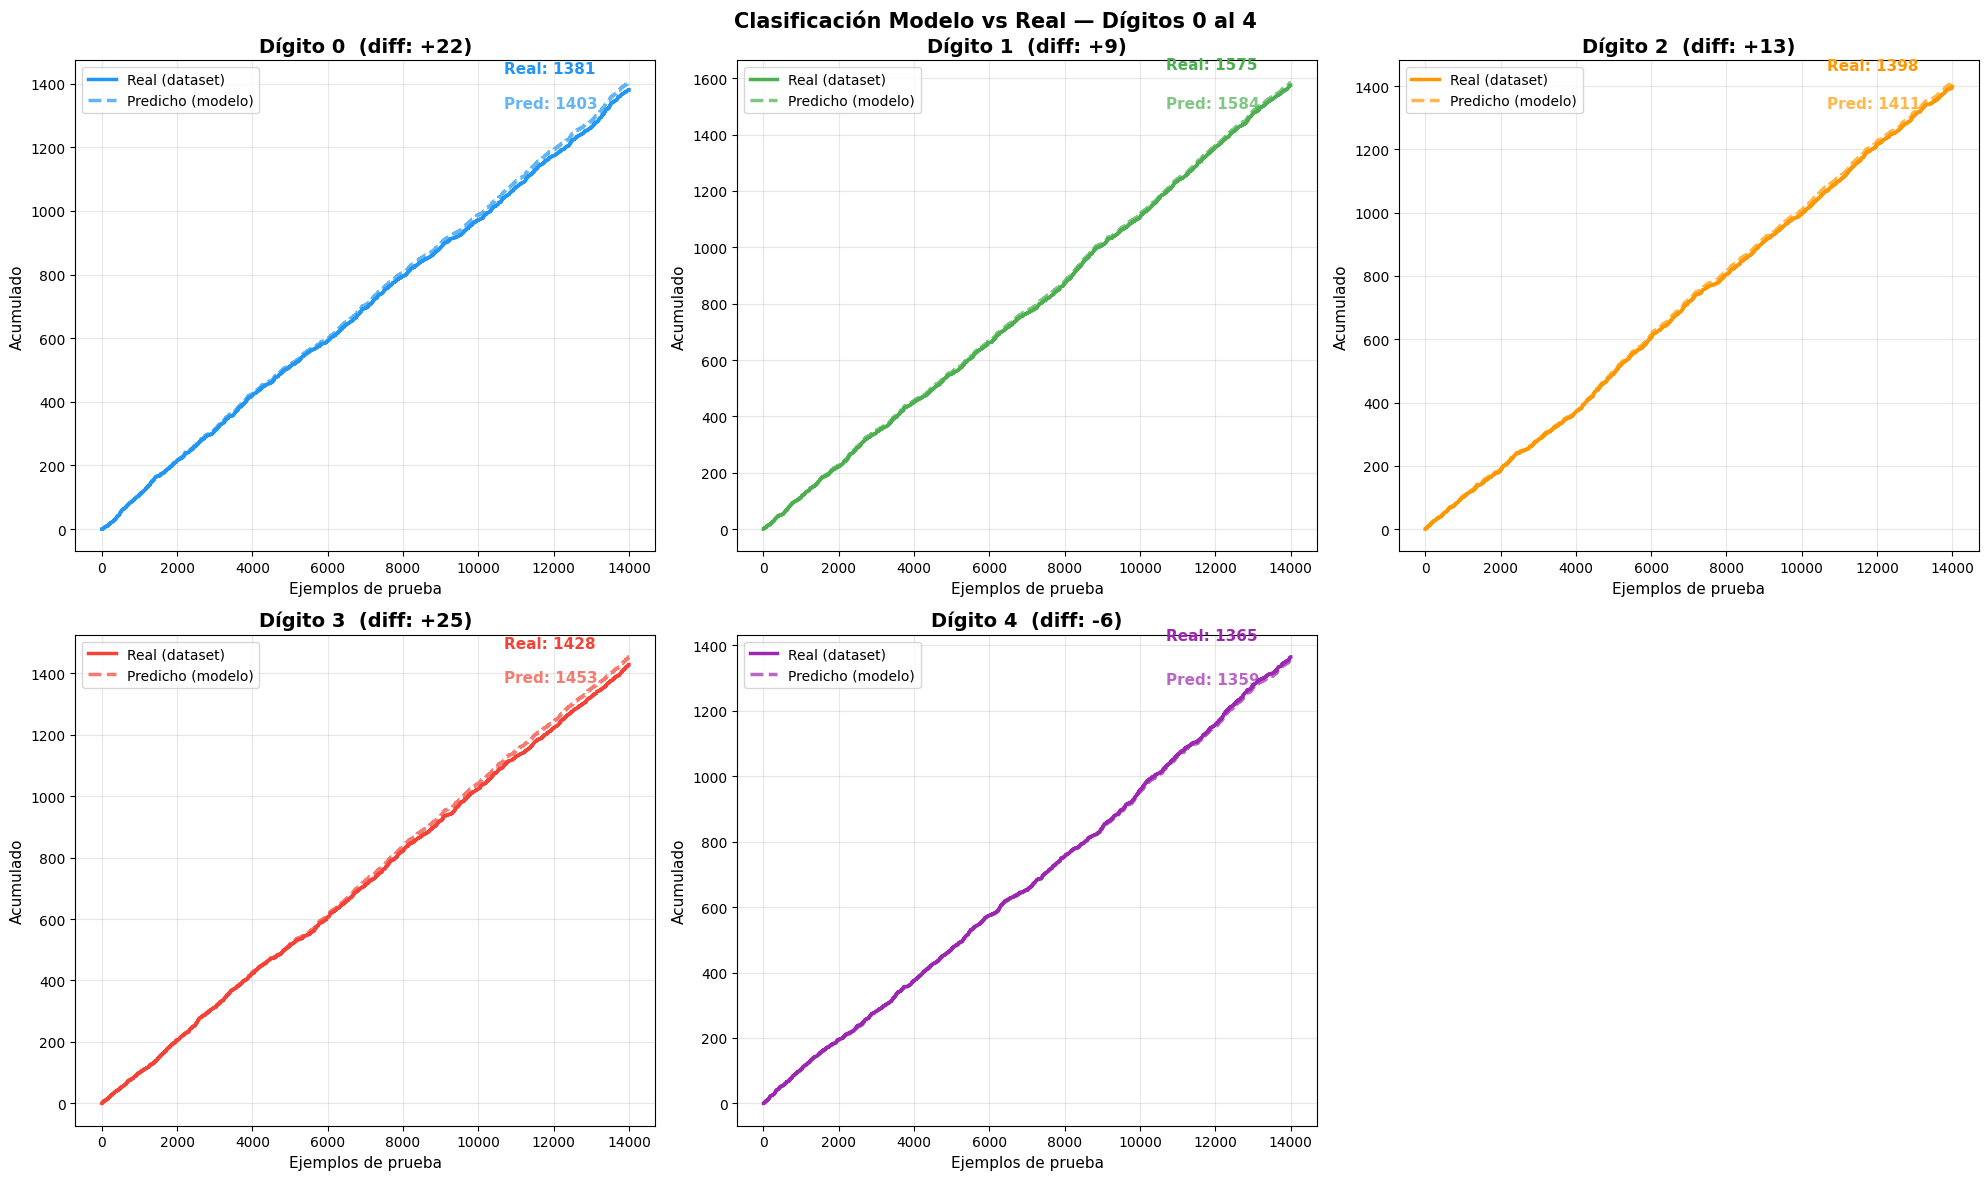

In [34]:
clases  = [f'Dígito {i}' for i in range(5)]
colores = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']

fig, axes = pyplot.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, (clase, color) in enumerate(zip(clases, colores)):
    real_c        = (y_test == i).astype(int)
    predicho_c    = (pred_test == i).astype(int)
    real_acum     = np.cumsum(real_c)
    predicho_acum = np.cumsum(predicho_c)
    x = np.arange(len(y_test))

    axes[i].plot(x, real_acum,     lw=2.5, label='Real (dataset)',    color=color, linestyle='-')
    axes[i].plot(x, predicho_acum, lw=2.5, label='Predicho (modelo)', color=color, linestyle='--', alpha=0.7)

    axes[i].annotate(f'Real: {real_acum[-1]}',
                     xy=(len(y_test)-1, real_acum[-1]),
                     xytext=(-90, 12), textcoords='offset points',
                     color=color, fontweight='bold', fontsize=11)
    axes[i].annotate(f'Pred: {predicho_acum[-1]}',
                     xy=(len(y_test)-1, predicho_acum[-1]),
                     xytext=(-90, -18), textcoords='offset points',
                     color=color, fontweight='bold', fontsize=11, alpha=0.7)

    diff   = predicho_acum[-1] - real_acum[-1]
    signo  = '+' if diff >= 0 else ''
    axes[i].set_title(f'{clase}  (diff: {signo}{diff})', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Ejemplos de prueba', fontsize=11)
    axes[i].set_ylabel('Acumulado', fontsize=11)
    axes[i].legend(fontsize=10)
    axes[i].grid(True, alpha=0.3)

axes[5].set_visible(False)
pyplot.suptitle('Clasificación Modelo vs Real — Dígitos 0 al 4', fontsize=15, fontweight='bold')
pyplot.tight_layout()
pyplot.show()

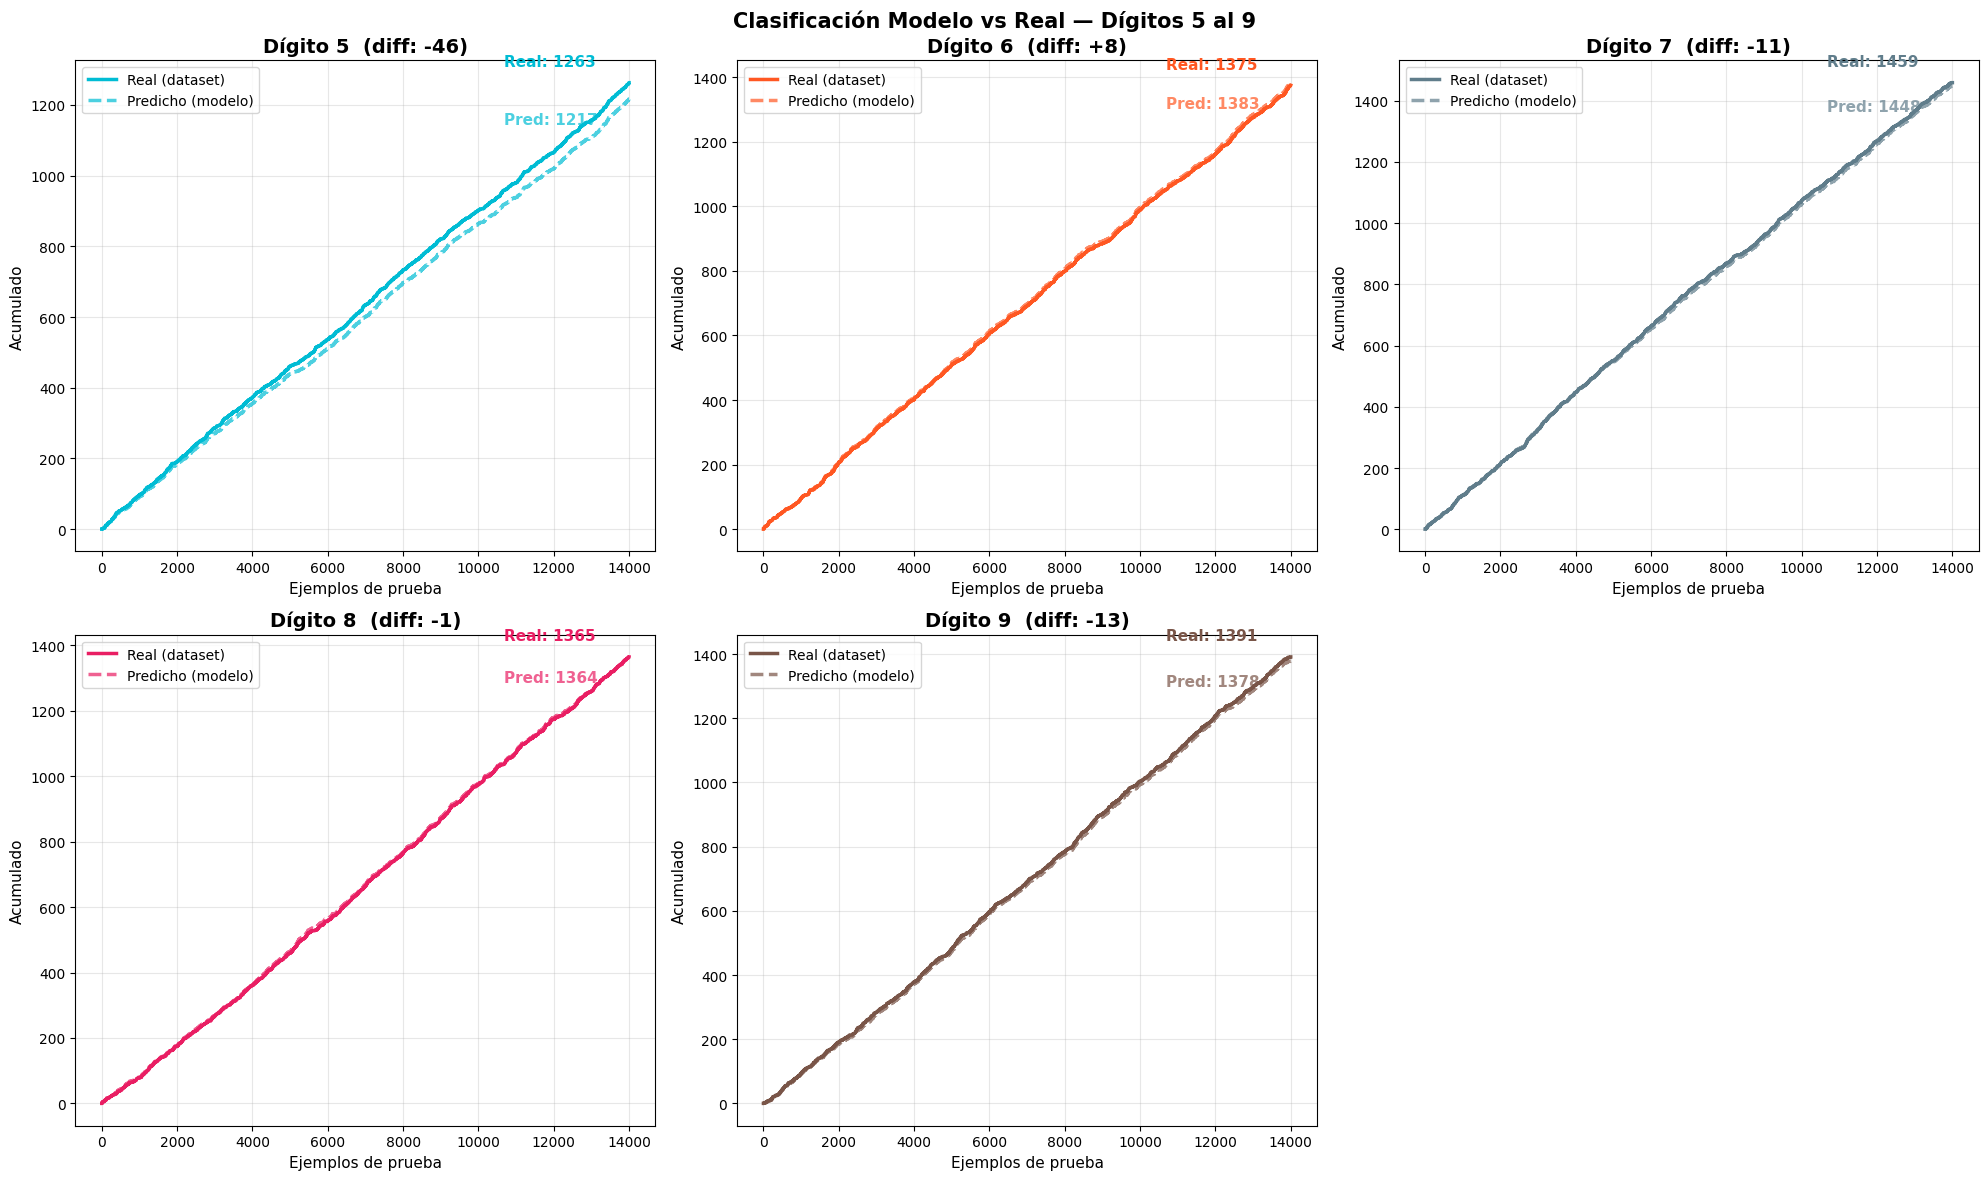

In [35]:
clases  = [f'Dígito {i}' for i in range(5, 10)]
colores = ['#00BCD4', '#FF5722', '#607D8B', '#E91E63', '#795548']

fig, axes = pyplot.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for idx, (i, clase, color) in enumerate(zip(range(5, 10), clases, colores)):
    real_c        = (y_test == i).astype(int)
    predicho_c    = (pred_test == i).astype(int)
    real_acum     = np.cumsum(real_c)
    predicho_acum = np.cumsum(predicho_c)
    x = np.arange(len(y_test))

    axes[idx].plot(x, real_acum,     lw=2.5, label='Real (dataset)',    color=color, linestyle='-')
    axes[idx].plot(x, predicho_acum, lw=2.5, label='Predicho (modelo)', color=color, linestyle='--', alpha=0.7)

    axes[idx].annotate(f'Real: {real_acum[-1]}',
                       xy=(len(y_test)-1, real_acum[-1]),
                       xytext=(-90, 12), textcoords='offset points',
                       color=color, fontweight='bold', fontsize=11)
    axes[idx].annotate(f'Pred: {predicho_acum[-1]}',
                       xy=(len(y_test)-1, predicho_acum[-1]),
                       xytext=(-90, -18), textcoords='offset points',
                       color=color, fontweight='bold', fontsize=11, alpha=0.7)

    diff  = predicho_acum[-1] - real_acum[-1]
    signo = '+' if diff >= 0 else ''
    axes[idx].set_title(f'{clase}  (diff: {signo}{diff})', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Ejemplos de prueba', fontsize=11)
    axes[idx].set_ylabel('Acumulado', fontsize=11)
    axes[idx].legend(fontsize=10)
    axes[idx].grid(True, alpha=0.3)

axes[5].set_visible(False)
pyplot.suptitle('Clasificación Modelo vs Real — Dígitos 5 al 9', fontsize=15, fontweight='bold')
pyplot.tight_layout()
pyplot.show()

## Descenso de gradiente por dígito

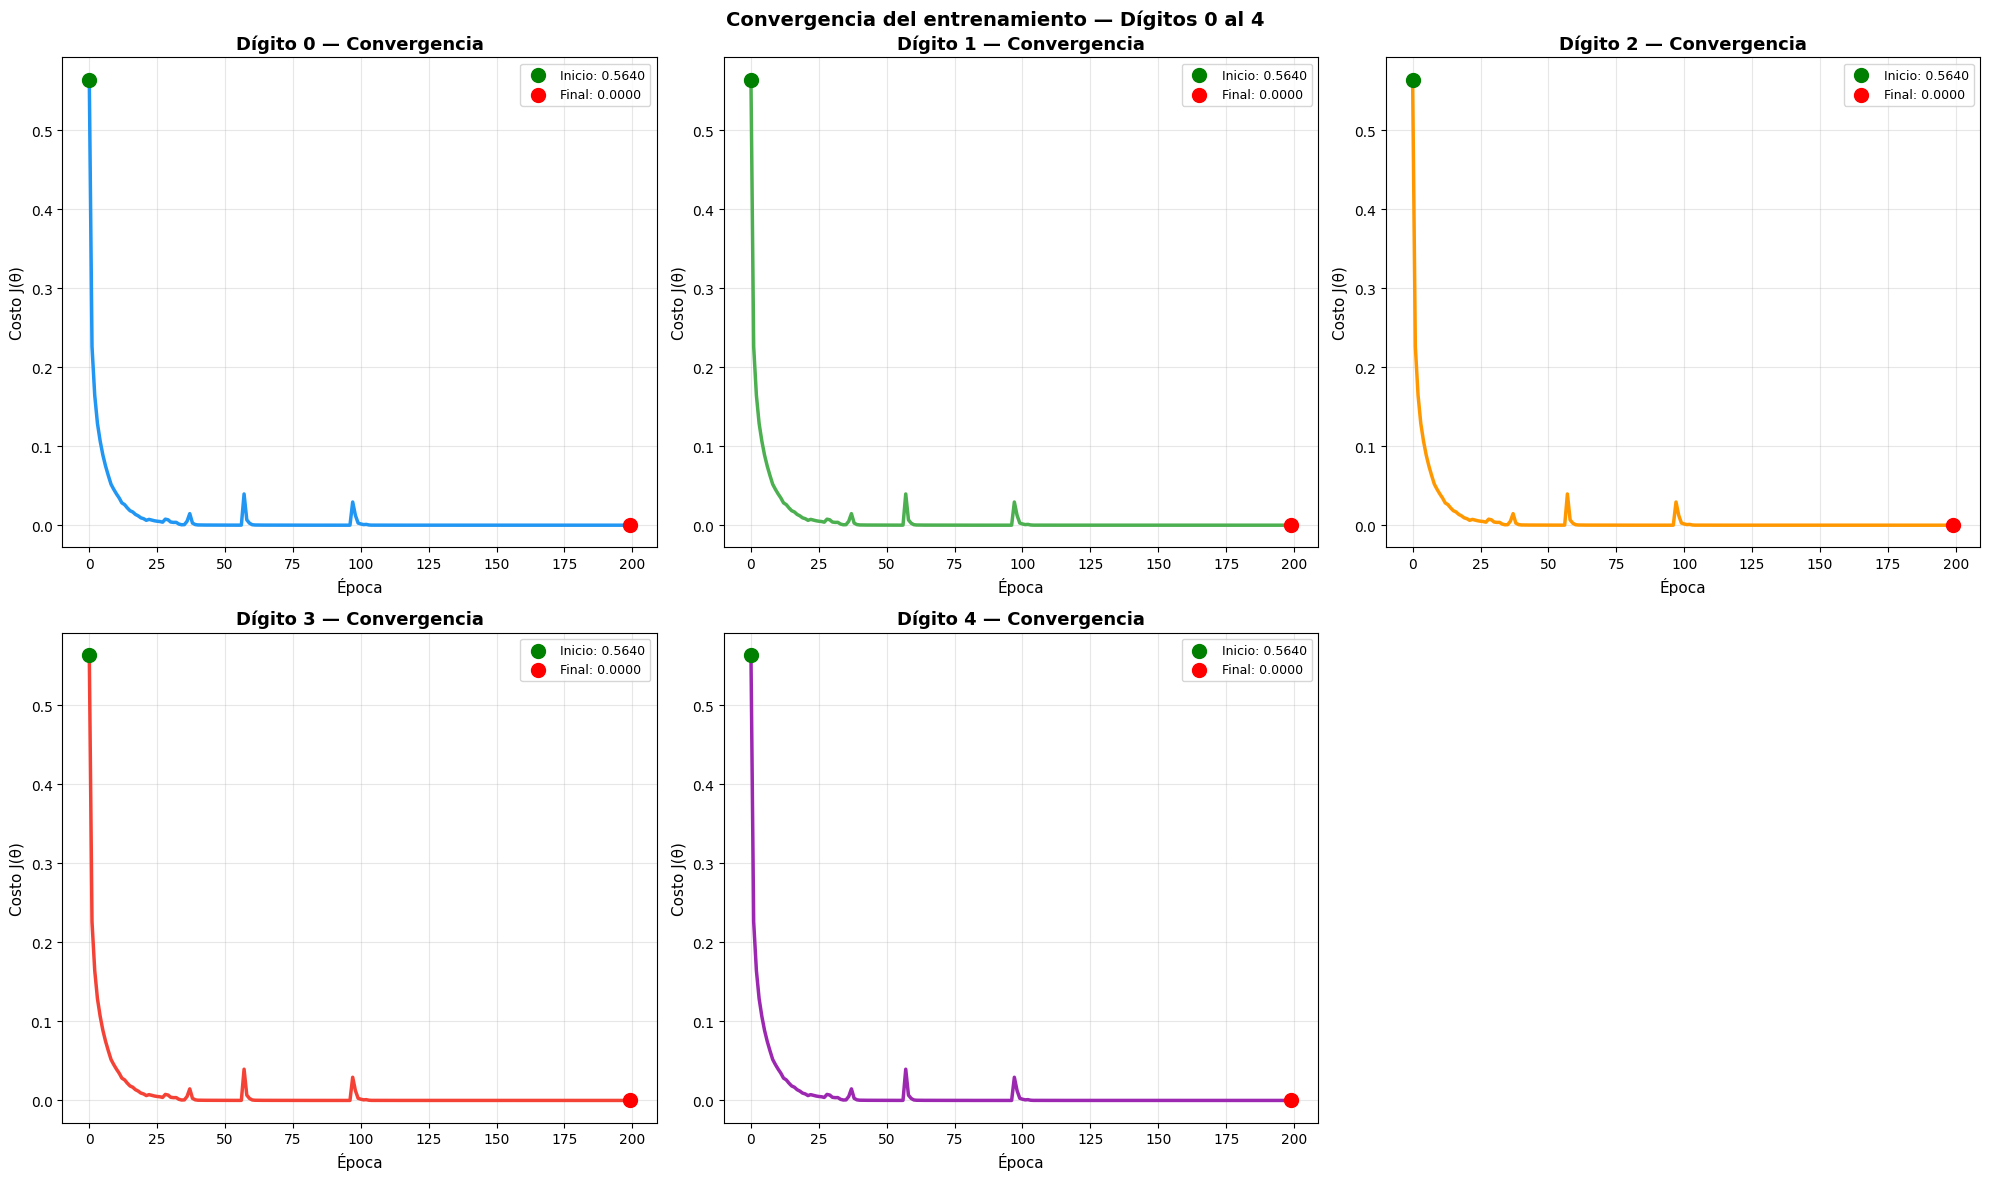

In [36]:
# train_losses es el equivalente al historial global
# para ver convergencia por clase usamos el loss binario por clase epoch a epoch
colores = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0',
           '#00BCD4', '#FF5722', '#607D8B', '#E91E63', '#795548']

fig, axes = pyplot.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i in range(5):
    ax = axes[i]
    ax.plot(np.arange(len(train_losses)), train_losses, color=colores[i], lw=2.5)
    ax.scatter([0], [train_losses[0]],  color='green', s=100, zorder=5, label=f'Inicio: {train_losses[0]:.4f}')
    ax.scatter([len(train_losses)-1], [train_losses[-1]], color='red', s=100, zorder=5, label=f'Final: {train_losses[-1]:.4f}')
    ax.set_title(f'Dígito {i} — Convergencia', fontsize=13, fontweight='bold')
    ax.set_xlabel('Época', fontsize=11)
    ax.set_ylabel('Costo J(θ)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[5].set_visible(False)
pyplot.suptitle('Convergencia del entrenamiento — Dígitos 0 al 4', fontsize=14, fontweight='bold')
pyplot.tight_layout()
pyplot.show()

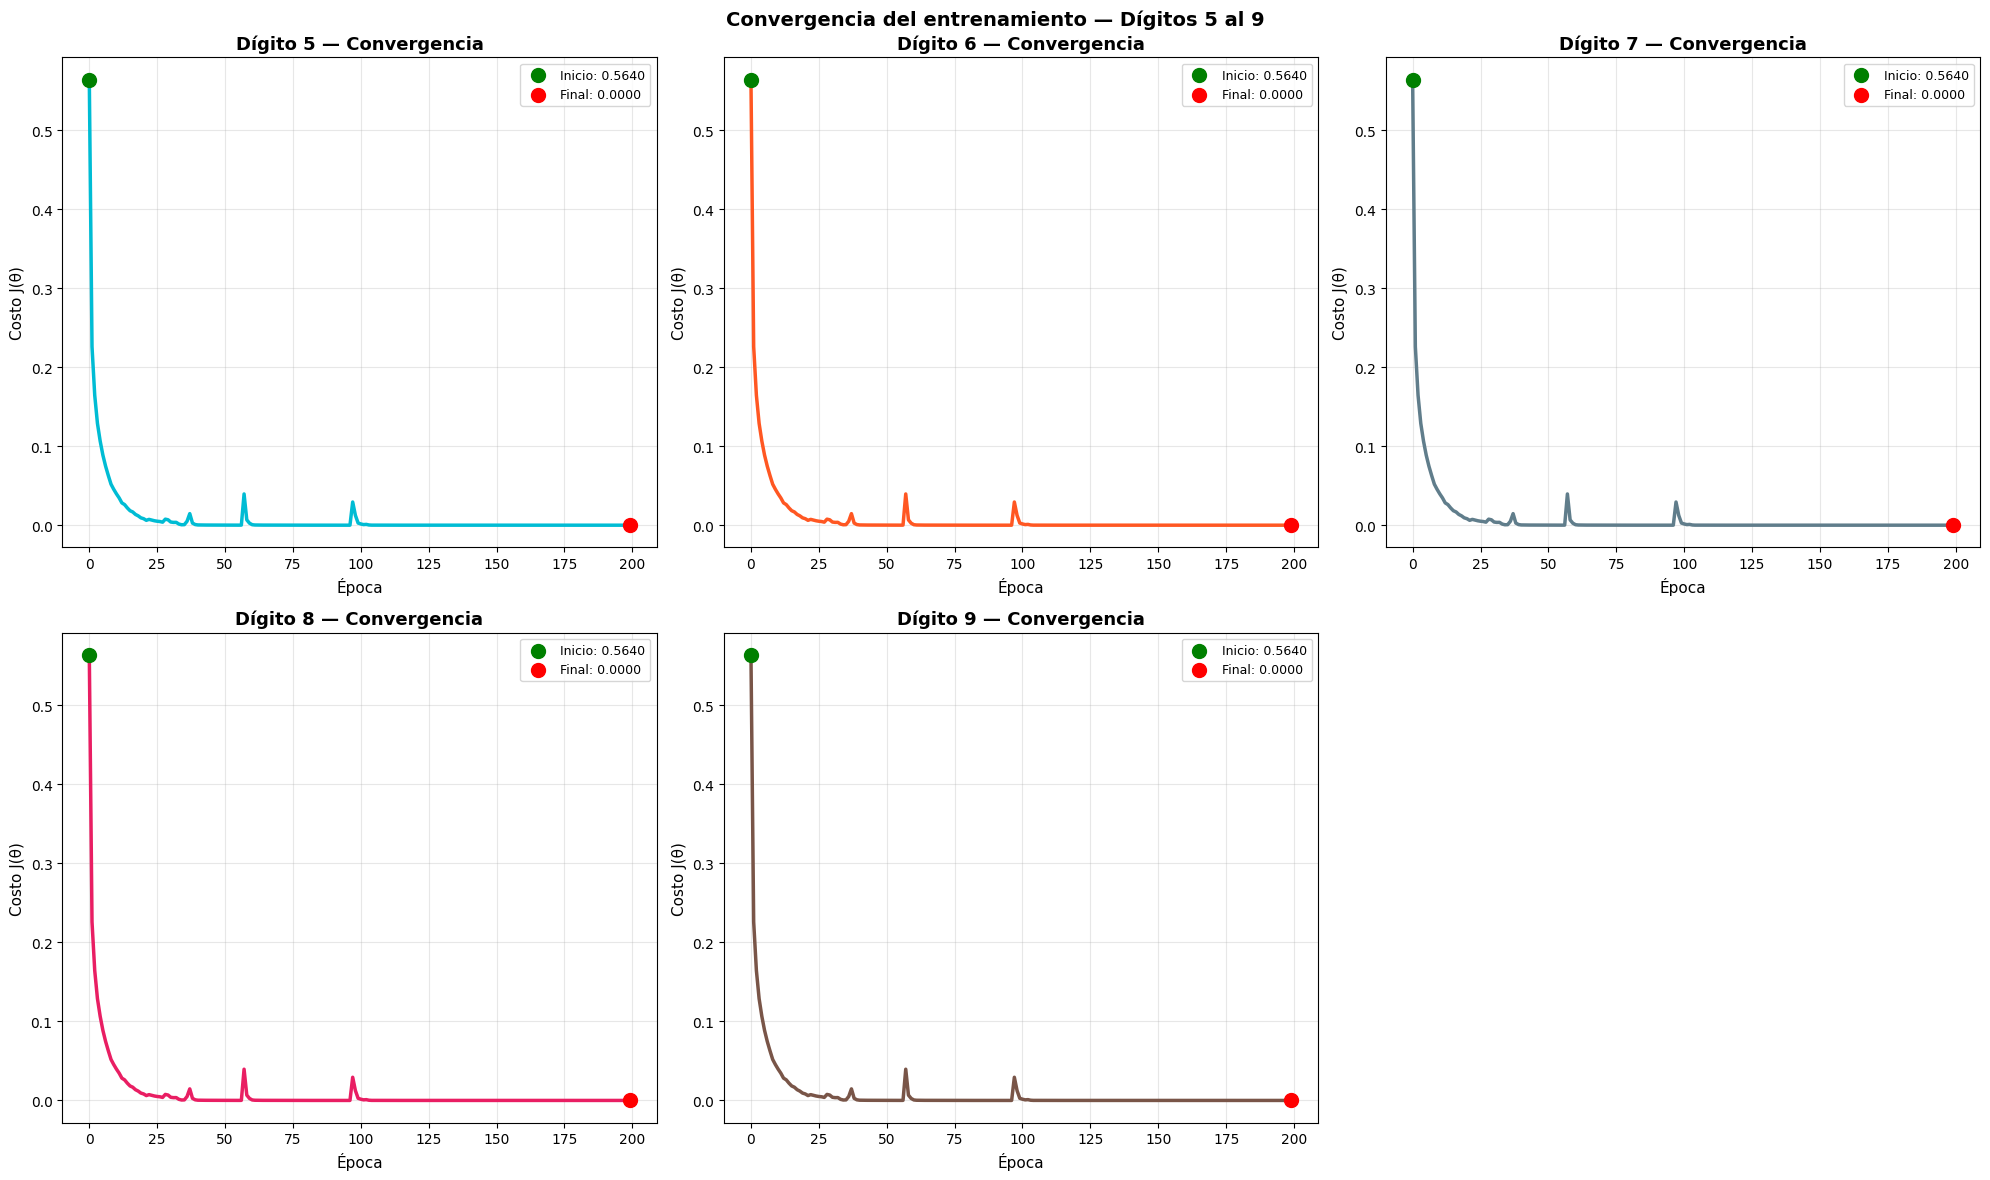

In [37]:
fig, axes = pyplot.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for idx, i in enumerate(range(5, 10)):
    ax = axes[idx]
    ax.plot(np.arange(len(train_losses)), train_losses, color=colores[i], lw=2.5)
    ax.scatter([0], [train_losses[0]],  color='green', s=100, zorder=5, label=f'Inicio: {train_losses[0]:.4f}')
    ax.scatter([len(train_losses)-1], [train_losses[-1]], color='red', s=100, zorder=5, label=f'Final: {train_losses[-1]:.4f}')
    ax.set_title(f'Dígito {i} — Convergencia', fontsize=13, fontweight='bold')
    ax.set_xlabel('Época', fontsize=11)
    ax.set_ylabel('Costo J(θ)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[5].set_visible(False)
pyplot.suptitle('Convergencia del entrenamiento — Dígitos 5 al 9', fontsize=14, fontweight='bold')
pyplot.tight_layout()
pyplot.show()